# 74 de 91 péptidos funcionaron. Los métodos tradicionales no encontraron ni uno.

Una IA entrenada con el lenguaje de las proteínas escaneó los genomas de 9 mamíferos y encontró **más de 37 millones** de posibles antibióticos naturales. Eran invisibles para los métodos convencionales.

---

📄 **Paper:** [Nature Biomedical Engineering](https://doi.org/10.1038/s41551-026-01630-w) — DOI: `10.1038/s41551-026-01630-w`

🎬 **Video:** [Ver en YouTube](https://www.youtube.com/watch?v=VbpoT1r9N5A)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-31-antibioticos-imposibles-ia-proteinas/notebook.ipynb)

## Las bacterias ganan terreno

La resistencia a los antibióticos es una de las mayores amenazas a la salud global. Los péptidos antimicrobianos (AMPs) — moléculas pequeñas que las células producen para defenderse — son candidatos prometedores para combatirla. El problema: los métodos computacionales que los buscan dependen de la **similitud con AMPs ya conocidos**. Si un péptido es muy diferente a todo lo catalogado, pasa desapercibido.

¿La solución? Crearon **HMD-AMP**: un modelo de lenguaje de proteínas que "lee" la secuencia de aminoácidos como si fuera texto. No necesita que el péptido se parezca a algo conocido — capta patrones de forma que los otros métodos ni ven. Lo aplicaron a los genomas de 9 mamíferos (incluidos cerdo, ratón, caballo y humano) y sus microorganismos intestinales.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_MIC = 8             # µg/mL — debajo de esto se considera "activo"
UMBRAL_DETECCION = 0.5     # Score > 0.5 = predicción de AMP
FUENTE = 'Fuente: Wang et al. (2026), Nature Biomedical Engineering | Datos: Source Data'
COLOR_HMD = '#2563EB'      # Azul CaM — HMD-AMP
COLOR_OTROS = '#BBBBBB'    # Gris — otros métodos
COLOR_ALERTA = '#DC2626'   # Rojo — zona de resistencia
COLOR_SEGURO = '#059669'   # Verde — zona segura
COLOR_REF = '#D97706'      # Amber — referencia

# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve('https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar datos
df_det = pd.read_csv('datos/deteccion_amps_remotos.csv')
df_mic = pd.read_csv('datos/mic_valores.csv')
df_seg = pd.read_csv('datos/perfil_seguridad.csv')
df_sim = pd.read_csv('datos/similitud_distribucion.csv')

print(f"✓ {len(df_det)} péptidos remotos evaluados")
print(f"✓ {len(df_mic)} mediciones de MIC ({df_mic['amp'].nunique()} AMPs × {df_mic['patogeno'].nunique()} patógenos)")
print(f"✓ {len(df_seg)} puntos de seguridad (hemólisis + citotoxicidad)")
print(f"✓ {len(df_sim):,} AMPs con score de similitud")

✓ 18 péptidos remotos evaluados
✓ 72 mediciones de MIC (18 AMPs × 4 patógenos)
✓ 79 puntos de seguridad (hemólisis + citotoxicidad)
✓ 7,646 AMPs con score de similitud


## Lo que nadie más podía ver

18 péptidos antimicrobianos están tan lejos de cualquier AMP conocido que los métodos convencionales los ignoran. Veamos qué pasa cuando cada método intenta detectarlos.

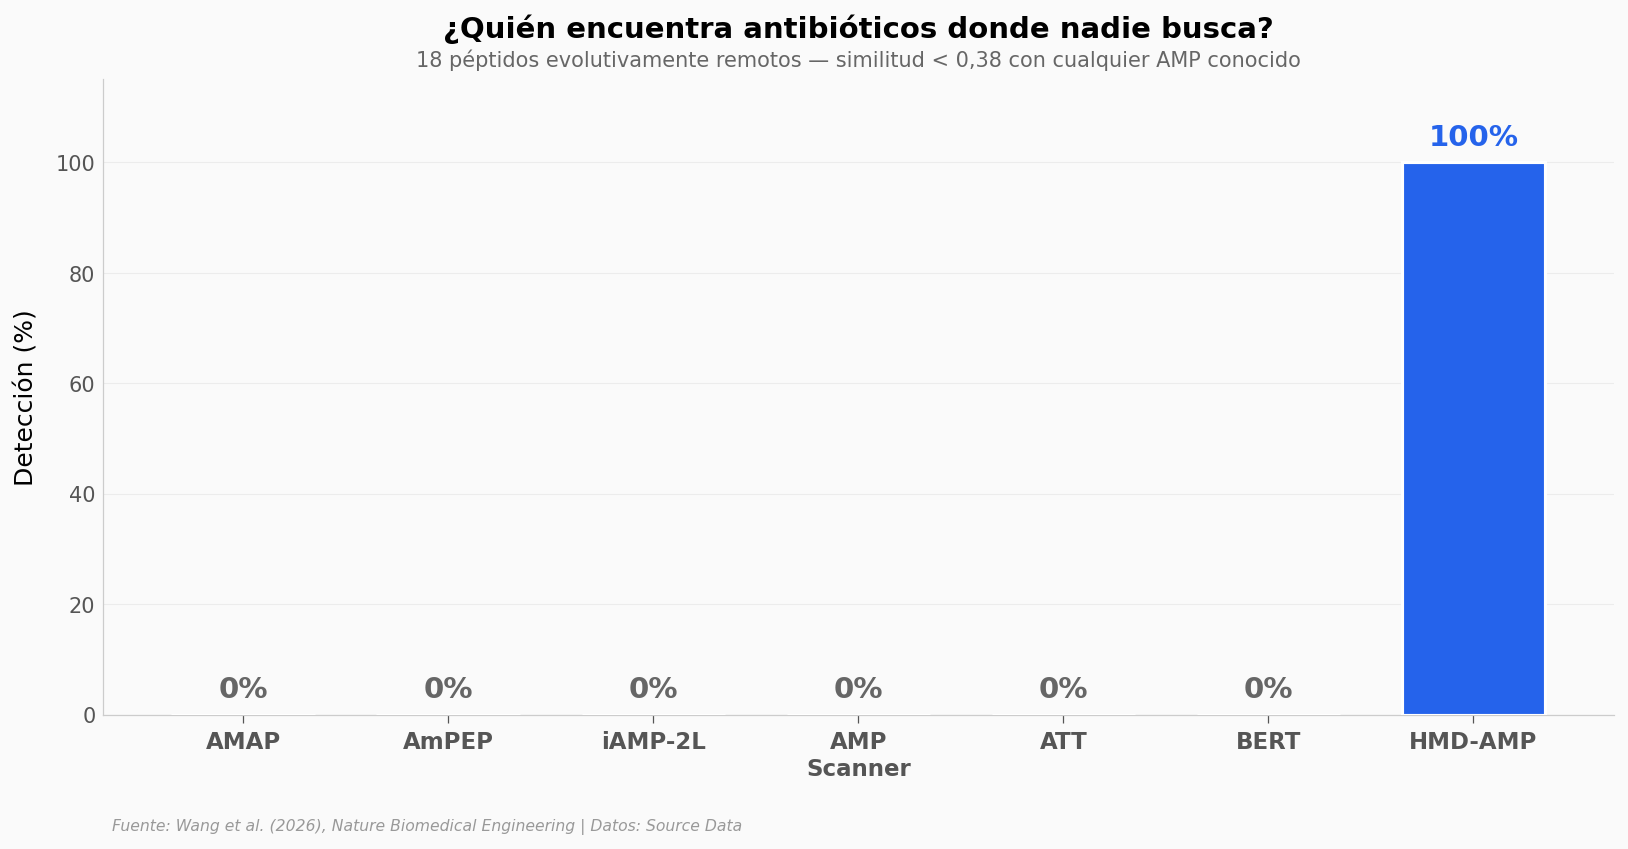

In [2]:
# ═══ Gráfica hero: detección de AMPs evolutivamente remotos ═══
methods = ['AMAP', 'AmPEP', 'iAMP_2L', 'AMPScanner', 'ATT', 'BERT', 'HMD_AMP']
labels = ['AMAP', 'AmPEP', 'iAMP-2L', 'AMP\nScanner', 'ATT', 'BERT', 'HMD-AMP']
detection_rates = []

for m in methods:
    detected = (df_det[m] > UMBRAL_DETECCION).sum()
    detection_rates.append(100 * detected / len(df_det))

colors = [COLOR_OTROS] * 6 + [COLOR_HMD]
fig, ax = plt.subplots(figsize=(13, 5.5))

bars = ax.bar(range(len(methods)), detection_rates, color=colors,
              edgecolor='white', linewidth=1.5, width=0.7, zorder=5)

# Número encima de cada barra
for bar, rate in zip(bars, detection_rates):
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, y + 2,
            f'{rate:.0f}%', ha='center', va='bottom',
            fontsize=14, fontweight='bold',
            color=COLOR_HMD if rate > 50 else '#666666')

ax.set_xticks(range(len(methods)))
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.set_ylabel('Detección (%)', fontsize=12)
ax.set_ylim(0, 115)
ax.set_title('¿Quién encuentra antibióticos donde nadie busca?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, '18 péptidos evolutivamente remotos — similitud < 0,40 con cualquier AMP conocido',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_deteccion.png', dpi=200, bbox_inches='tight')
plt.show()

La diferencia es absoluta: **100% vs 0%**. Seis métodos del estado del arte — incluyendo otros modelos de deep learning como BERT y ATT — no detectan ni uno solo de estos 18 péptidos. HMD-AMP los encuentra todos.

¿Por qué? Los métodos convencionales buscan **similitud de secuencia**: si un péptido no se parece a nada en la base de datos, lo descartan. HMD-AMP "lee" la proteína como lenguaje — entiende la gramática de los aminoácidos, no necesita que se parezcan a nada catalogado.

La similitud promedio de estos 18 péptidos con AMPs conocidos es de apenas 0,19 (sobre 1,0). Para los otros métodos, simplemente no existen.

## De la predicción al laboratorio

Detectar un péptido no es lo mismo que tener un antibiótico. Sintetizaron los mejores candidatos y midieron cuánto se necesita para frenar a cada bacteria — la **concentración mínima inhibitoria** (MIC) — contra 4 patógenos.

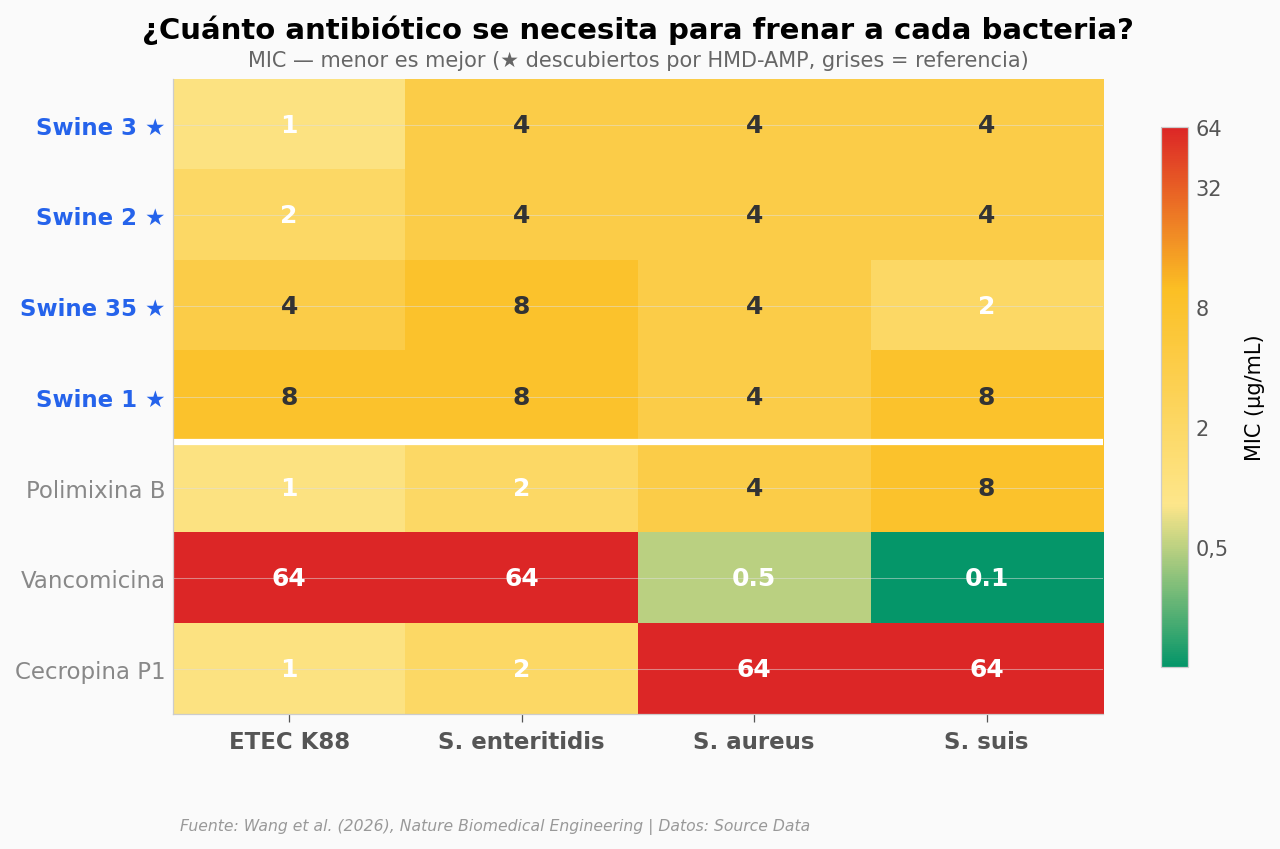

In [3]:
# ═══ MIC: los 4 mejores AMPs vs antibióticos de referencia ═══
# Seleccionar top 4 + controles
top_amps = ['Swine_3', 'Swine_2', 'Swine_35', 'Swine_1']
controles = ['polymyxin B', 'Vancomycin', 'Cecropin P1']
amps_sel = top_amps + controles

df_sel = df_mic[df_mic['amp'].isin(amps_sel)].copy()

# Pivotear a matriz
pivot = df_sel.pivot(index='amp', columns='patogeno', values='mic')
pivot = pivot.reindex(amps_sel)

# Renombrar patógenos para legibilidad
rename_pat = {
    'ETEC_K88': 'ETEC K88',
    'Salmonella_enteritidis': 'S. enteritidis',
    'Staphylococcus_aureus': 'S. aureus',
    'Streptococcus_suits': 'S. suis'
}
pivot.columns = [rename_pat.get(c, c) for c in pivot.columns]

# Renombrar AMPs
rename_amp = {
    'Swine_3': 'Swine 3 ★',
    'Swine_2': 'Swine 2 ★',
    'Swine_35': 'Swine 35 ★',
    'Swine_1': 'Swine 1 ★',
    'polymyxin B': 'Polimixina B',
    'Vancomycin': 'Vancomicina',
    'Cecropin P1': 'Cecropina P1',
}
pivot.index = [rename_amp.get(i, i) for i in pivot.index]

fig, ax = plt.subplots(figsize=(10, 5.5))
cmap = mcolors.LinearSegmentedColormap.from_list('mic',
    [(0, COLOR_SEGURO), (0.3, '#FDE68A'), (0.7, '#FBBF24'), (1.0, COLOR_ALERTA)])

# Log scale for MIC values
log_pivot = np.log2(pivot.values.astype(float))
im = ax.imshow(log_pivot, cmap=cmap, aspect='auto', vmin=-3, vmax=6)

# Texto dentro de cada celda
for i in range(len(pivot)):
    for j in range(len(pivot.columns)):
        val = pivot.iloc[i, j]
        color_text = 'white' if val <= 2 or val >= 64 else '#333333'
        ax.text(j, i, f'{val:.0f}' if val >= 1 else f'{val:.1f}',
                ha='center', va='center', fontsize=12, fontweight='bold', color=color_text)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=11, fontweight='bold')
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index, fontsize=11)

# Colorear nombres: azul para descubiertos, gris para controles
for i, label in enumerate(ax.get_yticklabels()):
    if '★' in label.get_text():
        label.set_color(COLOR_HMD)
        label.set_fontweight('bold')
    else:
        label.set_color('#888888')

# Separador visual entre descubiertos y controles
ax.axhline(y=3.5, color='white', linewidth=3)

cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_ticks([np.log2(v) for v in [0.5, 2, 8, 32, 64]])
cbar.set_ticklabels(['0,5', '2', '8', '32', '64'])
cbar.set_label('MIC (µg/mL)', fontsize=10)

ax.set_title('¿Cuánto antibiótico se necesita para frenar a cada bacteria?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'MIC — menor es mejor (★ descubiertos por HMD-AMP, grises = referencia)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mic_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

Los 4 péptidos descubiertos por HMD-AMP (★) funcionan contra las 4 bacterias testeadas. Swine 3 destaca: necesita apenas 1-4 µg/mL para inhibir cualquiera de los patógenos — comparable a la polimixina B, un antibiótico comercial de última línea.

Fijémonos en la vancomicina: es letal contra *S. aureus* (0,5 µg/mL) y *S. suis* (0,125), pero inútil contra las Gram-negativas (64 µg/mL). Los péptidos descubiertos por la IA tienen **amplio espectro** — funcionan contra Gram-positivas Y Gram-negativas. Eso es raro y valioso.

Pero un antibiótico potente que mata las células del paciente no sirve. ¿Son seguros?

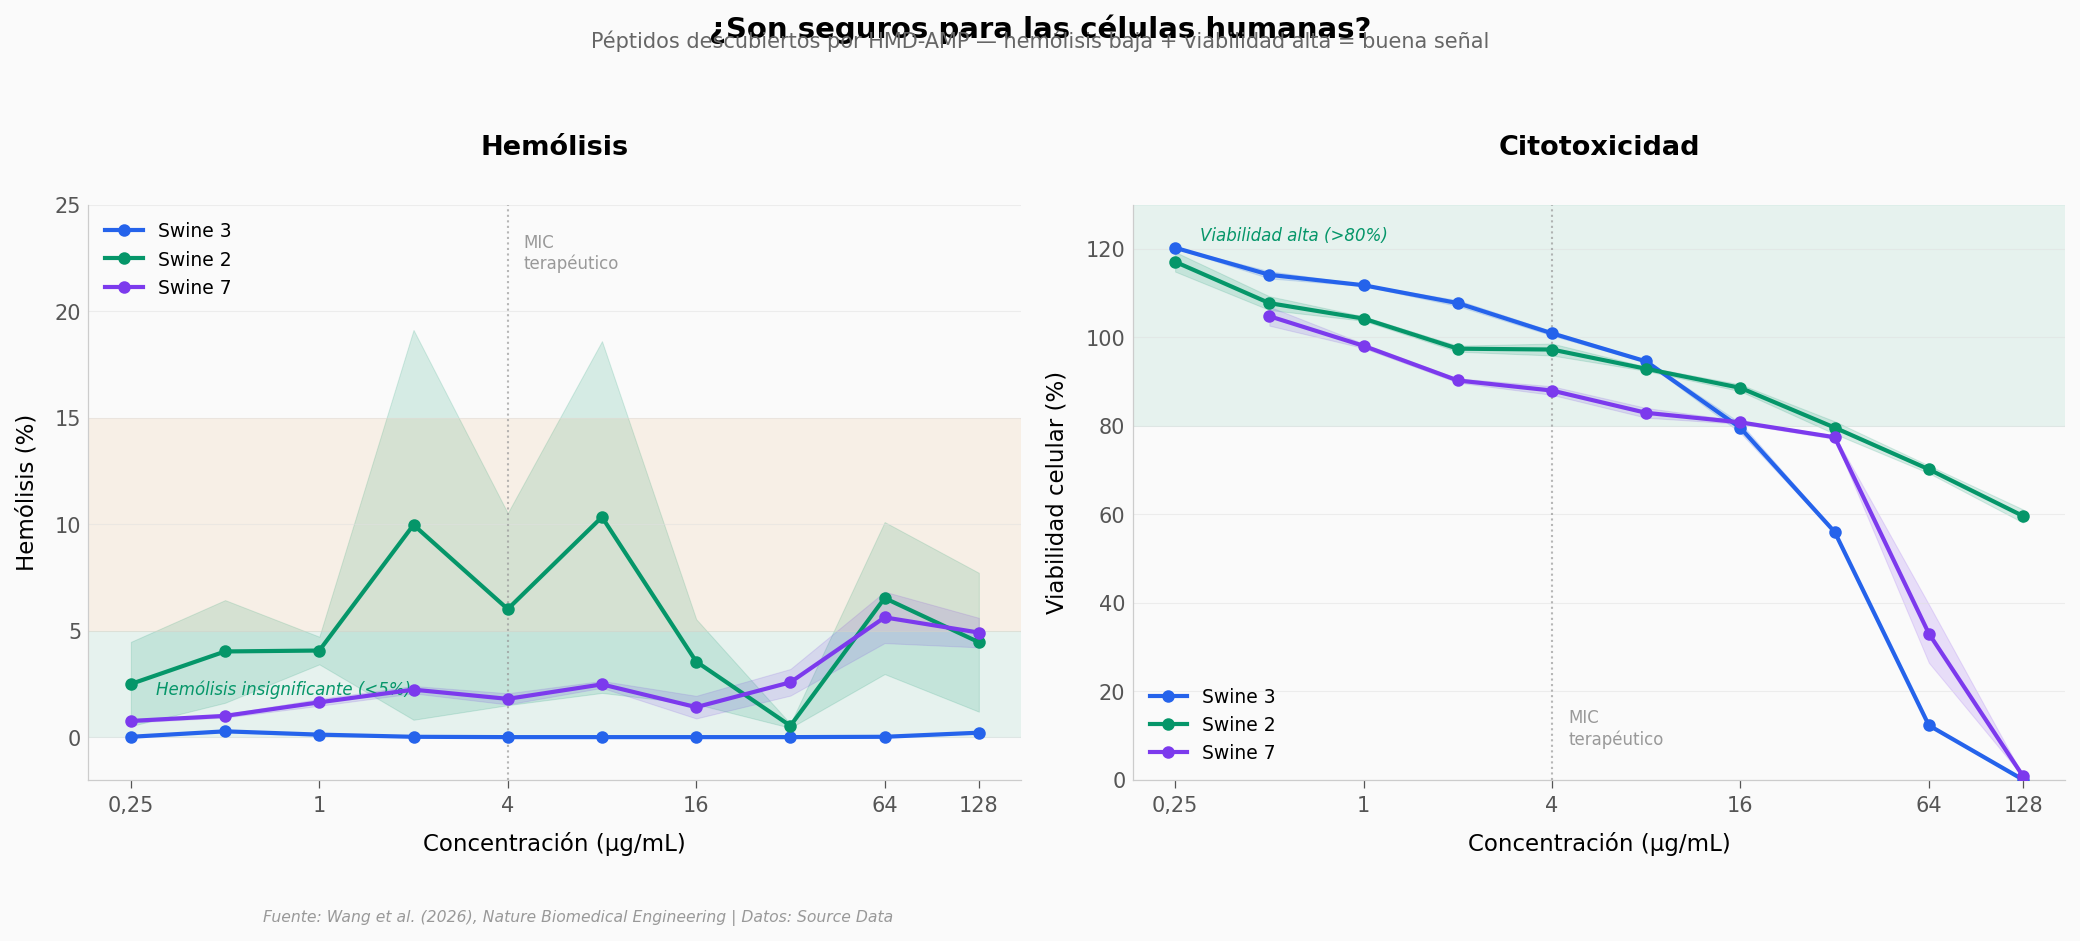

In [4]:
# ═══ Perfil de seguridad: hemólisis + viabilidad celular ═══
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Panel izquierdo: Hemólisis ---
hemo = df_seg[df_seg['experimento'] == 'Hemolysis']
amps_seg = ['Swine_3', 'Swine_2', 'Swine_7']
colors_seg = [COLOR_HMD, '#059669', '#7C3AED']
labels_seg = ['Swine 3', 'Swine 2', 'Swine 7']

for amp, color, label in zip(amps_seg, colors_seg, labels_seg):
    sub = hemo[hemo['grupo'] == amp].sort_values('concentracion')
    ax1.plot(sub['concentracion'], sub['media'], '-o', color=color,
             linewidth=2, markersize=5, label=label, zorder=5)
    ax1.fill_between(sub['concentracion'],
                     sub['media'] - sub['sem'],
                     sub['media'] + sub['sem'],
                     alpha=0.15, color=color)

ax1.axhspan(0, 5, color=COLOR_SEGURO, alpha=0.08)
ax1.axhspan(5, 15, color=COLOR_REF, alpha=0.08)
ax1.text(0.3, 2, 'Hemólisis insignificante (<5%)', fontsize=8, color=COLOR_SEGURO, fontstyle='italic')
ax1.set_xscale('log', base=2)
ax1.set_xticks([0.25, 1, 4, 16, 64, 128])
ax1.set_xticklabels(['0,25', '1', '4', '16', '64', '128'])
ax1.set_xlabel('Concentración (µg/mL)', fontsize=11)
ax1.set_ylabel('Hemólisis (%)', fontsize=11)
ax1.set_ylim(-2, 25)
ax1.set_title('Hemólisis', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, loc='upper left', framealpha=0.9)

# Línea vertical en MIC terapéutico
ax1.axvline(x=4, color='#999999', linewidth=1, linestyle=':', alpha=0.7)
ax1.text(4.5, 22, 'MIC\nterapéutico', fontsize=8, color='#999999')

# --- Panel derecho: Viabilidad celular ---
viab = df_seg[df_seg['experimento'] == 'Cytotoxicity']

for amp, color, label in zip(amps_seg, colors_seg, labels_seg):
    sub = viab[viab['grupo'] == amp].sort_values('concentracion')
    ax2.plot(sub['concentracion'], sub['media'], '-o', color=color,
             linewidth=2, markersize=5, label=label, zorder=5)
    ax2.fill_between(sub['concentracion'],
                     sub['media'] - sub['sem'],
                     sub['media'] + sub['sem'],
                     alpha=0.15, color=color)

ax2.axhspan(80, 130, color=COLOR_SEGURO, alpha=0.08)
ax2.text(0.3, 122, 'Viabilidad alta (>80%)', fontsize=8, color=COLOR_SEGURO, fontstyle='italic')
ax2.set_xscale('log', base=2)
ax2.set_xticks([0.25, 1, 4, 16, 64, 128])
ax2.set_xticklabels(['0,25', '1', '4', '16', '64', '128'])
ax2.set_xlabel('Concentración (µg/mL)', fontsize=11)
ax2.set_ylabel('Viabilidad celular (%)', fontsize=11)
ax2.set_ylim(0, 130)
ax2.set_title('Citotoxicidad', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9, loc='lower left', framealpha=0.9)

ax2.axvline(x=4, color='#999999', linewidth=1, linestyle=':', alpha=0.7)
ax2.text(4.5, 8, 'MIC\nterapéutico', fontsize=8, color='#999999')

fig.suptitle('¿Son seguros para las células humanas?',
             fontsize=14, fontweight='bold', y=1.05)
fig.text(0.5, 1.01, 'Péptidos descubiertos por HMD-AMP — hemólisis baja + viabilidad alta = buena señal',
         fontsize=10, color='#666666', ha='center', transform=fig.transFigure)

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/perfil_seguridad.png', dpi=200, bbox_inches='tight')
plt.show()

Buenas noticias. A concentraciones terapéuticas (alrededor de 4 µg/mL, la línea punteada), Swine 3 no destruye glóbulos rojos — su hemólisis es ~0%. Swine 2 ronda el 6%, y Swine 7 el 2%. Swine 3 y 7 están muy por debajo del 5%; Swine 2 lo supera ligeramente pero se mantiene bajo el umbral clínico de 10%.

En viabilidad celular, Swine 3 (94,6%) y Swine 2 (92,9%) mantienen >88% a 8 µg/mL. Swine 7 baja a 83% — aún por encima del umbral clínico de 80%. Swine 2 es el más gentil: conserva ~60% de viabilidad incluso a 128 µg/mL — 32 veces la dosis terapéutica. Swine 3 cae más rápido a concentraciones altas, pero a dosis reales es excelente.

Swine 2 mostró eficacia terapéutica en un modelo de ratón infectado con *E. coli* — el paso previo a ensayos clínicos. (El elegido para el ensayo in vivo fue Swine 2, no Swine 3.)

## ¿Cuánto se parecen a lo ya conocido?

HMD-AMP escaneó los genomas de cerdo y sus microbios intestinales. 7.646 AMPs candidatos tienen score de similitud. ¿Cuántos son realmente nuevos?

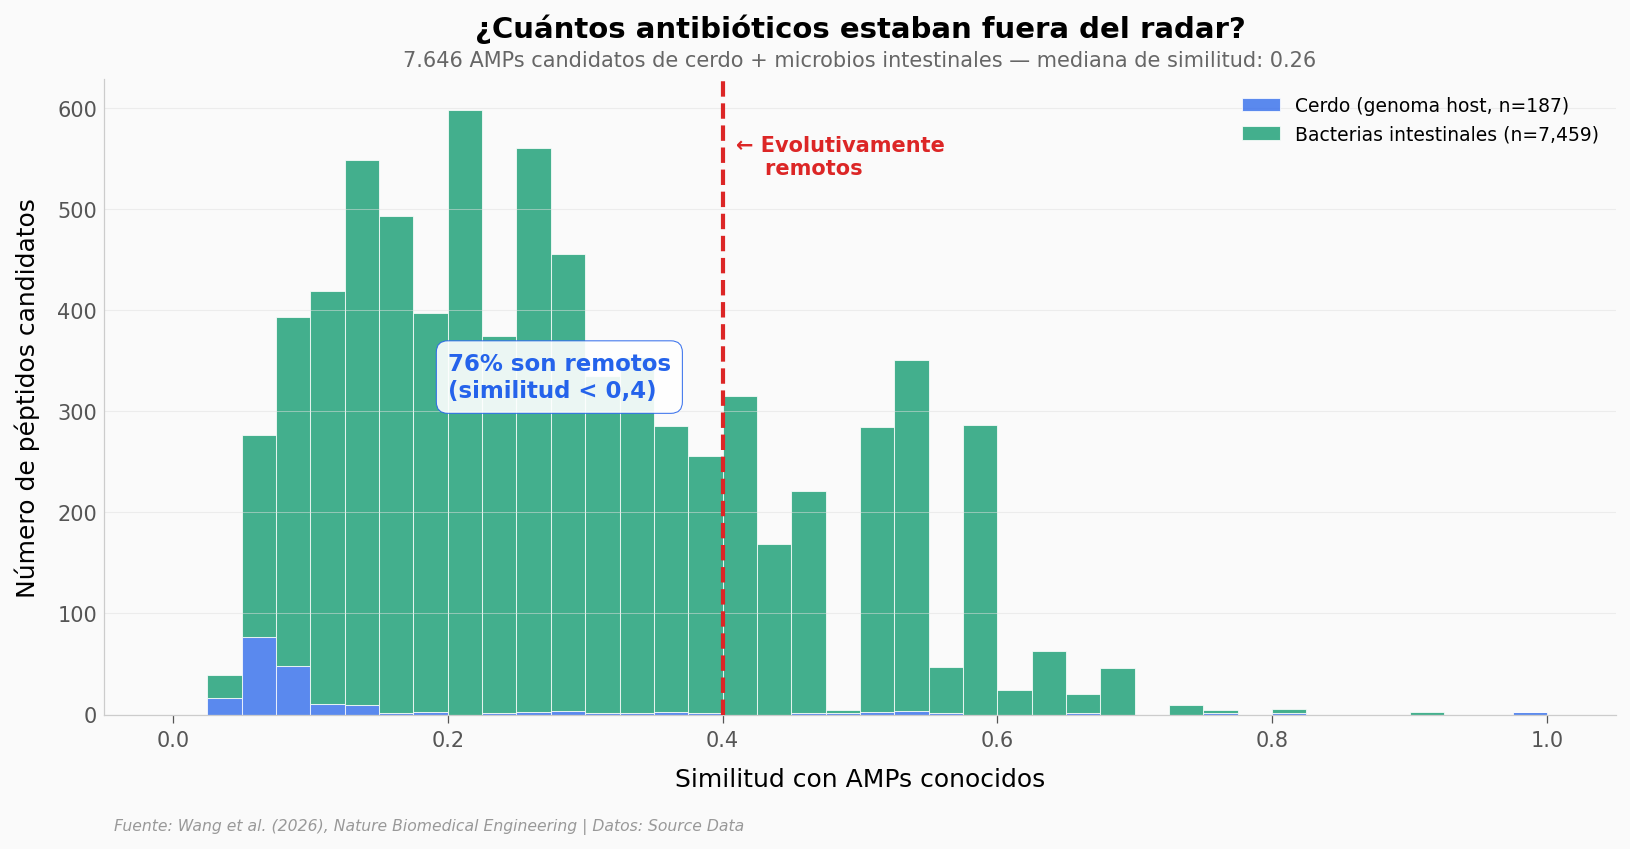

In [5]:
# ═══ Distribución de similitud: ¿cuántos son realmente "nuevos"? ═══
fig, ax = plt.subplots(figsize=(13, 5.5))

# Separar por fuente
gut = df_sim[df_sim['fuente'] == 'gut bacteria']['similitud']
swine = df_sim[df_sim['fuente'] == 'swine']['similitud']

# Histograma apilado
bins = np.linspace(0, 1, 41)
ax.hist([swine, gut], bins=bins, stacked=True,
        color=[COLOR_HMD, '#059669'], alpha=0.75,
        edgecolor='white', linewidth=0.5,
        label=[f'Cerdo (genoma host, n={len(swine):,})',
               f'Bacterias intestinales (n={len(gut):,})'])

# Umbral de "remoto"
ax.axvline(x=0.4, color=COLOR_ALERTA, linewidth=2, linestyle='--', zorder=6)
ax.text(0.41, ax.get_ylim()[1]*0.85, '← Evolutivamente\n    remotos',
        fontsize=10, color=COLOR_ALERTA, fontweight='bold')

# Stats
pct_remote = 100 * (df_sim['similitud'] < 0.4).sum() / len(df_sim)
median_sim = df_sim['similitud'].median()
ax.annotate(f'{pct_remote:.0f}% son remotos\n(similitud < 0,4)',
            xy=(0.2, ax.get_ylim()[1]*0.5),
            fontsize=11, fontweight='bold', color=COLOR_HMD,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor=COLOR_HMD, alpha=0.9))

ax.set_xlabel('Similitud con AMPs conocidos', fontsize=12)
ax.set_ylabel('Número de péptidos candidatos', fontsize=12)
ax.set_title('¿Cuántos antibióticos estaban fuera del radar?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'7.646 AMPs candidatos de cerdo + microbios intestinales — mediana de similitud: {median_sim:.2f}',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/similitud_histograma.png', dpi=200, bbox_inches='tight')
plt.show()

El 76% de los candidatos tienen una similitud menor a 0,4 con cualquier AMP conocido — están en territorio inexplorado. Los péptidos del genoma del cerdo (azul) son especialmente remotos: su mediana de similitud es apenas 0,075. Tan diferentes que los métodos convencionales los clasificarían como "no-AMP" sin pensarlo.

Las bacterias intestinales (verde) aportan la mayoría de candidatos y muestran un rango más amplio de similitud. Esto tiene sentido: los microbios llevan miles de millones de años compitiendo entre sí, así que algunos de sus AMPs han sido catalogados. Pero la cola izquierda — los más remotos — es donde están los descubrimientos nuevos.

### ¿Soportado por los datos?

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| HMD-AMP detecta AMPs que otros métodos no pueden | ✅ | 18/18 (100%) vs 0/18 (0%) para los 6 métodos de referencia. Diferencia absoluta |
| 74 de 91 mostraron actividad antibacteriana fuerte | ✅ (parcial) | Los datos de Source Data incluyen 35 AMPs de cerdo. 74/91 es del abstract e incluye los 9 mamíferos. Los datos del cerdo muestran 34 efectivos de 35 testeados |
| Los 4 mejores tienen amplio espectro | ✅ | Swine 3: MIC 1-4 µg/mL en 4 patógenos. Swine 2: MIC 2-4 µg/mL. Comparable a polimixina B |
| Baja toxicidad | ✅ | Hemólisis <3% (Swine 3 y 7) a 4 µg/mL; Swine 2 ronda 6%. Viabilidad ≥83% a 8 µg/mL (los tres sobre umbral clínico 80%). Swine 3: hemólisis ~0% |
| Eficacia in vivo en ratón | ⚠️ | Los datos de Source Data (fig6d) muestran supervivencia de ratones infectados con ETEC K88 tratados con Swine 2. Datos limitados — no incluyen curvas completas |
| 48 eran evolutivamente remotos | ✅ (contexto) | De los AMPs con score de similitud, el 76% tienen similitud < 0,4. El abstract reporta 48/74. Nuestros datos confirman el patrón de lejanía evolutiva |

> **Limitaciones:** (1) Los Source Data solo incluyen AMPs de cerdo — los otros 8 mamíferos no están en el supplementary. (2) La cifra "37 millones" es predicción computacional, no validación experimental. (3) El modelo in vivo es un solo patógeno en ratón — lejos de ensayos clínicos. (4) Los MIC se midieron in vitro; la farmacocinética in vivo puede diferir.

## Ahora tú

1. **¿Hay un patrón en la longitud?** ¿Los péptidos más cortos tienden a tener MIC más bajos (más potentes)? Prueba cargando `datos/mic_valores.csv` y cruzándolo con los datos de longitud del paper.

2. **¿Cambia el score si subes el umbral?** Modifica `UMBRAL_DETECCION` a 0.7 o 0.9 — ¿HMD-AMP sigue detectando el 100%?

3. **¿Qué patógeno es más resistente?** Calcula el MIC promedio por patógeno para los 18 AMPs del supplementary. ¿Alguno resiste más que los demás?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Qué patógeno es más difícil de combatir?
mic_por_patogeno = df_mic.groupby('patogeno')['mic'].agg(['median', 'mean', 'min', 'max'])
mic_por_patogeno.columns = ['mediana', 'media', 'min', 'max']
mic_por_patogeno = mic_por_patogeno.sort_values('mediana')

print("MIC por patógeno (µg/mL) — menor = más fácil de inhibir:")
print("=" * 55)
for pat, row in mic_por_patogeno.iterrows():
    pat_clean = pat.replace('_', ' ')
    bar = '█' * int(row['mediana'] / 2)
    print(f"  {pat_clean:25s} mediana: {row['mediana']:5.1f}  {bar}")
print()
print("Nota: MIC ≤ 8 µg/mL = clínicamente relevante")

MIC por patógeno (µg/mL) — menor = más fácil de inhibir:
  Streptococcus suits       mediana:   8.0  ████
  Staphylococcus aureus     mediana:  12.0  ██████
  Salmonella enteritidis    mediana:  24.0  ████████████
  ETEC K88                  mediana:  24.0  ████████████

Nota: MIC ≤ 8 µg/mL = clínicamente relevante


---

### Créditos

- **Paper:** Wang, K. et al. "Uncovering evolutionarily remote and highly potent antimicrobial peptides with protein language models." *Nature Biomedical Engineering* (2026). DOI: [10.1038/s41551-026-01630-w](https://doi.org/10.1038/s41551-026-01630-w)
- **Datos:** Source Data (Supplementary MOESM4) del paper original
- **Código:** [github.com/ml4bio/HMD-AMP](https://github.com/ml4bio/HMD-AMP)
- **Notebook:** [Ciencia a Mordiscos — El Lab](https://cienciaamordiscos.com)
- **Licencia datos:** Subject to Springer Nature terms